# 03 - Experiment Analysis

Displays the project's key result tables and figures already produced by the
experiment scripts under `experiments/`. No result here is recomputed; every
table is loaded directly from `results/tables/` and every number matches
`docs/final_report.md`.

## Four-way comparison: complete / imputed x with-or-without GA

In [1]:
import pandas as pd
from IPython.display import Image, display

four_way = pd.read_csv("../results/tables/four_way_comparison.csv")
four_way

,mechanism,missing_pct,imputer_used,feature_count_after,complete_rf_f1,complete_rf_roc_auc,complete_ga_rf_f1,complete_ga_rf_roc_auc,imputed_rf_f1,imputed_rf_roc_auc,imputed_ga_rf_f1,imputed_ga_rf_roc_auc
0,MAR,10,knn,6,0.666667,0.882542,0.705882,0.814506,0.742857,0.902439,0.666667,0.888318
1,MAR,20,knn,8,0.666667,0.882542,0.705882,0.814506,0.647059,0.863286,0.647059,0.865854
2,MAR,30,knn,5,0.666667,0.882542,0.705882,0.814506,0.833333,0.933248,0.756757,0.901797
3,MCAR,10,knn,7,0.666667,0.882542,0.705882,0.814506,0.666667,0.877407,0.647059,0.857510
4,MCAR,20,iterative,11,0.666667,0.882542,0.705882,0.814506,0.588235,0.774711,0.606061,0.792041
5,MCAR,30,iterative,7,0.666667,0.882542,0.705882,0.814506,0.444444,0.734917,0.500000,0.727856
6,MNAR,10,median,6,0.666667,0.882542,0.705882,0.814506,0.705882,0.905006,0.722222,0.876123
7,MNAR,20,median,2,0.666667,0.882542,0.705882,0.814506,0.500000,0.852375,0.416667,0.711168
8,MNAR,30,iterative,4,0.666667,0.882542,0.705882,0.814506,0.571429,0.783055,0.451613,0.748395


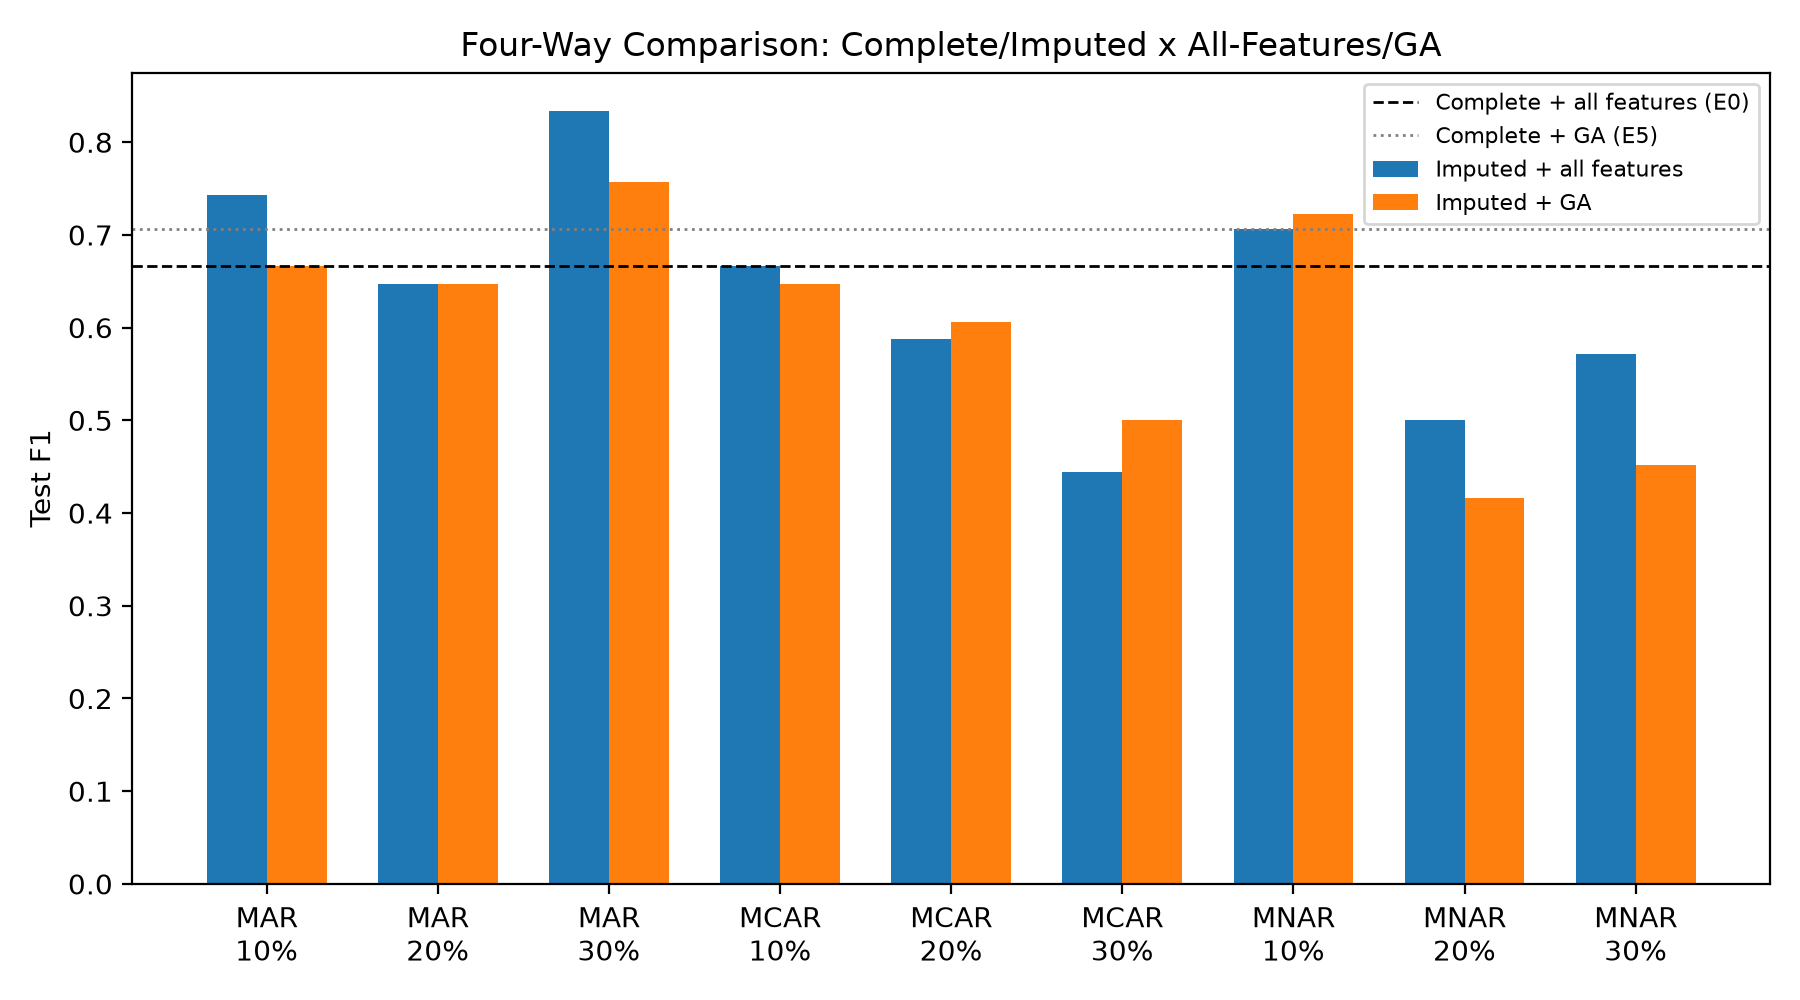

In [2]:
display(Image(filename="../results/figures/four_way_comparison.png"))

## GA feature-selection frequency (5 independent runs on complete data)

In [3]:
ga_freq = pd.read_csv("../results/tables/ga_feature_frequency.csv")
ga_freq

,feature,selection_count,selection_frequency
0,time,5,1.0
1,ejection_fraction,5,1.0
2,serum_creatinine,4,0.8
3,diabetes,3,0.6
4,serum_sodium,2,0.4
5,platelets,2,0.4
6,anaemia,2,0.4
7,creatinine_phosphokinase,1,0.2
8,sex,1,0.2
9,high_blood_pressure,1,0.2


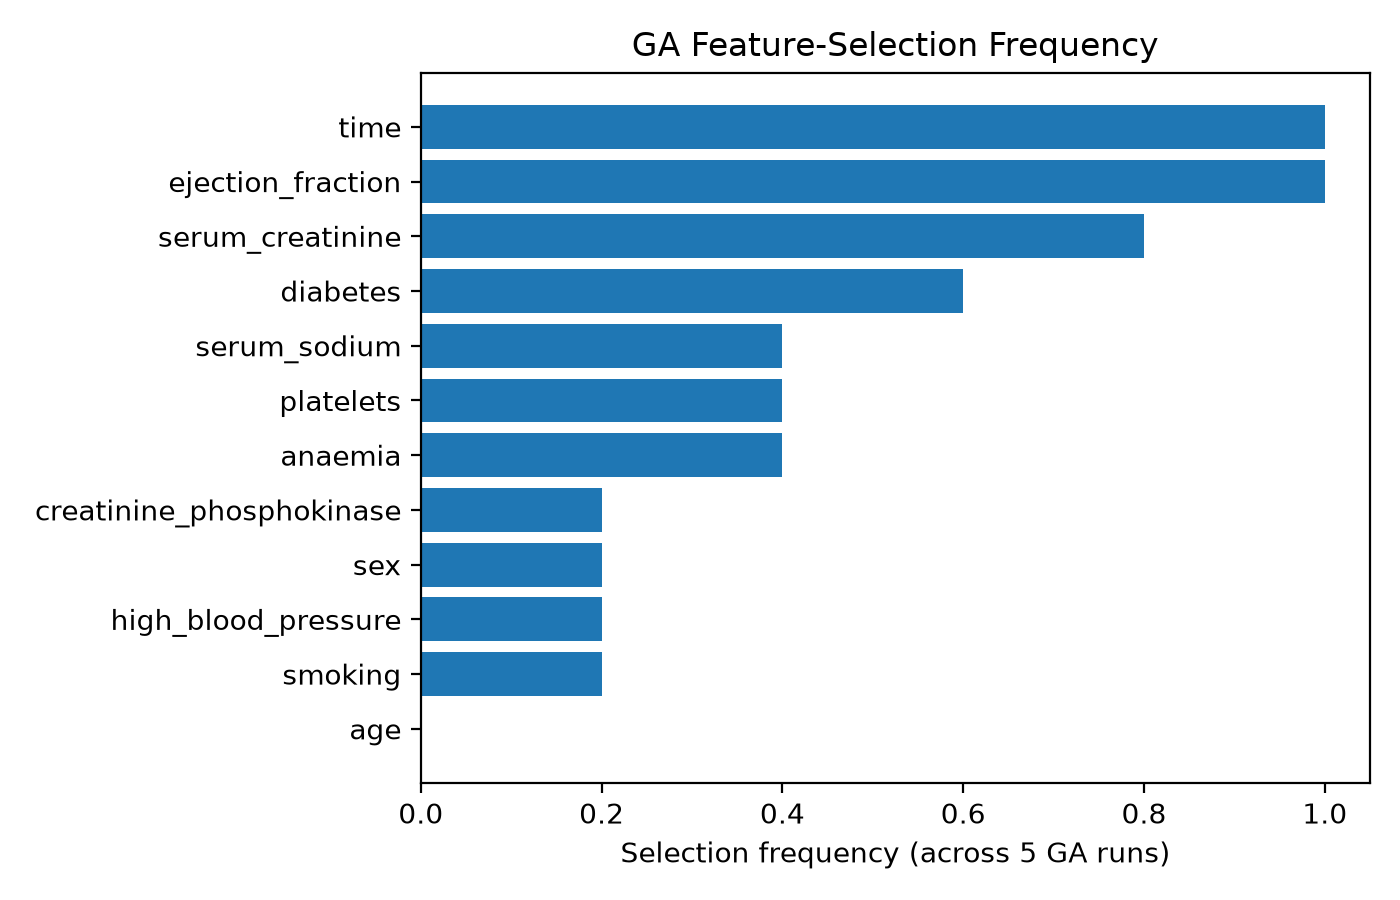

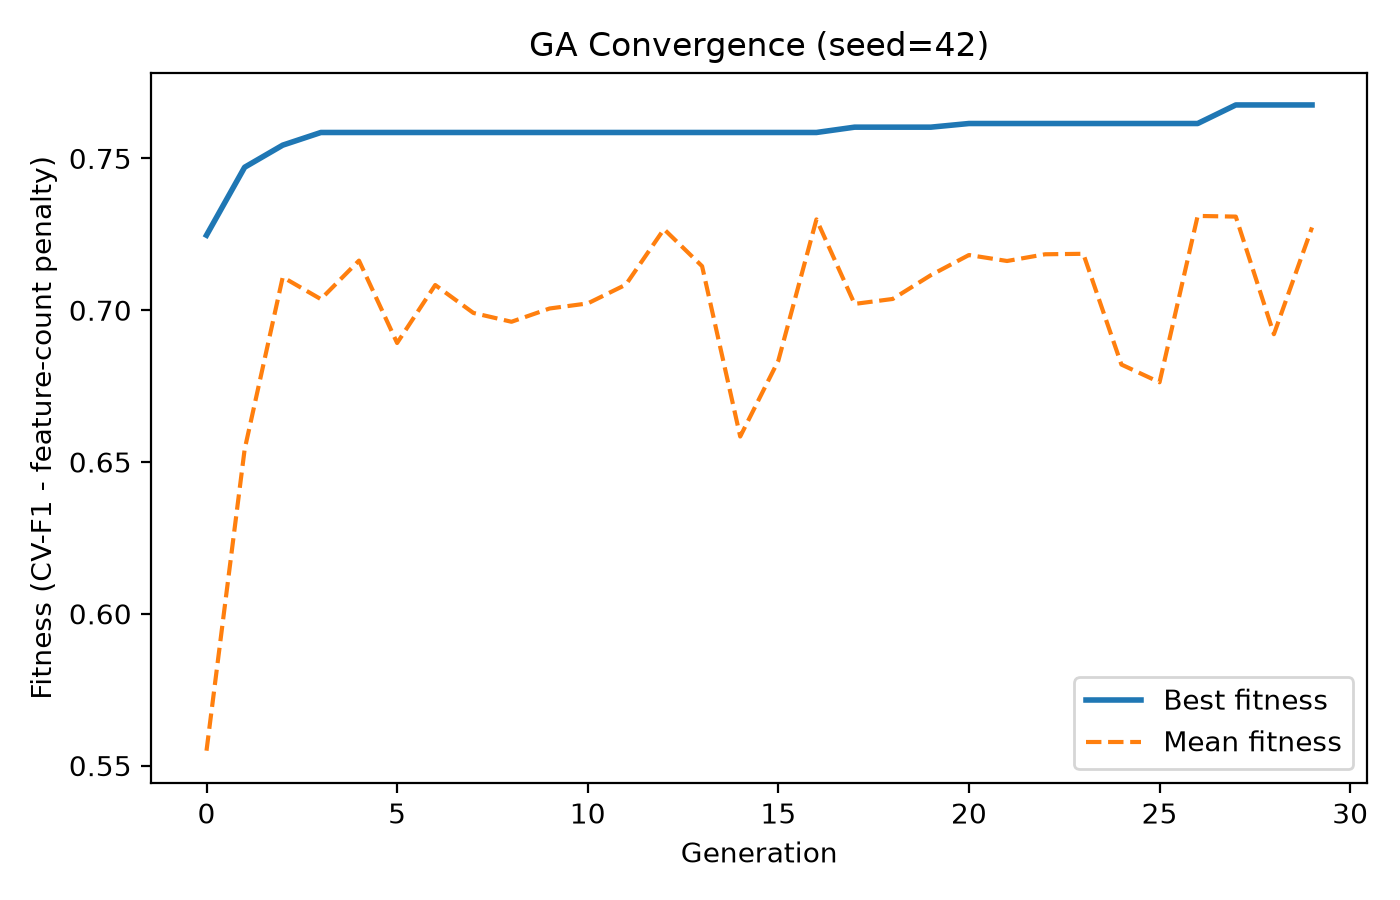

In [4]:
display(Image(filename="../results/figures/ga_feature_frequency.png"))
display(Image(filename="../results/figures/ga_convergence.png"))

## Paired statistical tests (27 comparisons across the 5-seed matrix)

In [5]:
stats = pd.read_csv("../results/tables/statistical_tests.csv")
stats

,comparison,a,b,mean_a,mean_b,n_pairs,t_stat,t_pvalue,wilcoxon_stat,wilcoxon_pvalue
0,imputer_vs_imputer:MAR_10pct,median,mean,0.737996,0.737048,5,0.156851,0.882961,1.0,1.0000
1,imputer_vs_imputer:MAR_20pct,knn,iterative,0.695630,0.695387,5,0.014237,0.989323,5.0,1.0000
2,imputer_vs_imputer:MAR_30pct,knn,mean,0.702389,0.691118,5,0.404686,0.706415,6.0,0.8125
3,imputer_vs_imputer:MCAR_10pct,knn,iterative,0.722378,0.715733,5,0.267489,0.802319,4.0,0.8750
4,imputer_vs_imputer:MCAR_20pct,mean,median,0.701780,0.695398,5,0.267158,0.802556,4.0,0.8750
5,imputer_vs_imputer:MCAR_30pct,knn,iterative,0.645075,0.637051,5,0.604706,0.578000,5.0,0.6250
6,imputer_vs_imputer:MNAR_10pct,knn,median,0.742253,0.738019,5,0.327035,0.760040,4.0,0.8750
7,imputer_vs_imputer:MNAR_20pct,median,knn,0.636883,0.627137,5,0.899118,0.419423,1.0,0.5000
8,imputer_vs_imputer:MNAR_30pct,knn,iterative,0.636651,0.628080,5,0.209472,0.844316,4.0,0.8750
9,mechanism_vs_mechanism:10pct,MCAR(knn),MAR(median),0.722378,0.737996,5,-1.196766,0.297478,3.0,0.3125


In [6]:
significant = stats[stats["t_pvalue"] < 0.05]
significant[["comparison", "a", "b", "mean_a", "mean_b", "t_pvalue"]]

,comparison,a,b,mean_a,mean_b,t_pvalue
18,missingness_cost:10pct,E0_complete,MCAR(knn),0.77599,0.722378,0.017482
21,missingness_cost:20pct,E0_complete,MCAR(mean),0.77599,0.701780,0.011911
23,missingness_cost:20pct,E0_complete,MNAR(median),0.77599,0.636883,0.008281
26,missingness_cost:30pct,E0_complete,MNAR(knn),0.77599,0.636651,0.023628


## RQ1-RQ4 summary (from `docs/research_question_analysis.md` / `docs/final_report.md`)

- **RQ1** (does missingness affect prediction?): supported - 4 of 9
  complete-vs-imputed comparisons are significant at p<0.05, while 0 of 18
  imputer-vs-imputer and mechanism-vs-mechanism comparisons are significant.
  Missingness itself, not the specific mechanism, is the measurable driver.
- **RQ2** (which imputer is best?): no imputer is statistically distinguishable
  from another at this sample size (0 of 9 significant).
- **RQ3** (does GA improve prediction?): GA reliably selects a stable,
  clinically plausible feature subset (`time`, `ejection_fraction` in 5 of 5
  runs) but does not reliably improve accuracy once tested across multiple
  seeds rather than a single split.
- **RQ4** (how does the full pipeline compare?): summarised in the four-way
  comparison table above and discussed against selected literature in
  `docs/final_report.md` Section 19 (no cross-dataset numbers presented as
  head-to-head).